<a href="https://colab.research.google.com/github/muraleee/oreilly-langgraph/blob/main/RAG_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U --quiet \
    "langchain>=1.0.0a" \
    langchain-openai \
    langchain-community \
    langgraph \
    langsmith \
    langchain-mcp-adapters \
    faiss-cpu \
    openai \
    chromadb \
    langchain-chroma \
    langchain-huggingface \
    beautifulsoup4 \
    google-search-results \
    python-dotenv \
    tiktoken \
    mcp \
    sentence-transformers \
    pandas

In [2]:
from google.colab import userdata
import os
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [3]:
from typing import TypedDict, Any
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

# Blog posts from https://ai-office-hours.beehiiv.com/
BLOG_URLS = [
    "https://kubernetes.io/docs/concepts/architecture/nodes/",
    "https://kubernetes.io/docs/concepts/overview/working-with-objects/labels/",
    "https://kubernetes.io/docs/concepts/overview/working-with-objects/namespaces/",
    "https://kubernetes.io/docs/concepts/containers/images/",
    "https://kubernetes.io/docs/concepts/workloads/pods/",
    "https://kubernetes.io/docs/concepts/workloads/pods/init-containers/"
]


class IngestionState(TypedDict):
    urls: list[str]
    raw_documents: list[Document]
    chunks: list[Document]
    vectorstore: Any  # Chroma instance — passed through state for downstream use


def scrape_node(state: IngestionState) -> dict:
    """Scrape blog posts using LangChain's WebBaseLoader."""
    print(f"Scraping {len(state['urls'])} URLs...")
    loader = WebBaseLoader(state["urls"])
    docs = loader.load()
    print(f"  Loaded {len(docs)} documents")
    for doc in docs:
        title = doc.metadata.get("title", "Untitled")
        print(f"  - {title[:60]} ({len(doc.page_content)} chars)")
    return {"raw_documents": docs}


def chunk_node(state: IngestionState) -> dict:
    """Split documents into retrieval-sized chunks."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        separators=["\n\n", "\n", ". "],
    )
    chunks = splitter.split_documents(state["raw_documents"])
    print(f"Split {len(state['raw_documents'])} documents into {len(chunks)} chunks")
    return {"chunks": chunks}


def embed_and_store_node(state: IngestionState) -> dict:
    """Embed chunks using a local open-source model and store in Chroma."""
    # all-MiniLM-L6-v2: fast, small (80MB), runs entirely on CPU — no API key needed
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
    vectorstore = Chroma.from_documents(
        state["chunks"],
        embeddings,
        collection_name="ai_office_hours",
    )
    print(f"Embedded and stored {len(state['chunks'])} chunks in Chroma")
    return {"vectorstore": vectorstore}


# Build the ingestion graph
ingestion_graph = StateGraph(IngestionState)
ingestion_graph.add_node("scrape", scrape_node)
ingestion_graph.add_node("chunk", chunk_node)
ingestion_graph.add_node("embed_and_store", embed_and_store_node)

ingestion_graph.add_edge(START, "scrape")
ingestion_graph.add_edge("scrape", "chunk")
ingestion_graph.add_edge("chunk", "embed_and_store")
ingestion_graph.add_edge("embed_and_store", END)

ingestion_app = ingestion_graph.compile()

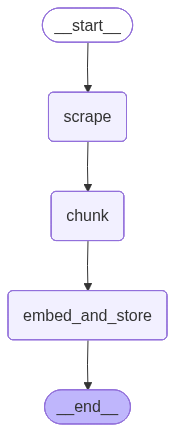

In [4]:
from IPython.display import Image, display

display(Image(ingestion_app.get_graph().draw_mermaid_png()))

In [5]:
#Run ingestion — scrapes live blog content, chunks it, embeds with HuggingFace, stores in Chroma
result = ingestion_app.invoke({"urls": BLOG_URLS})

# Pull the vectorstore out of the graph result for use in Part 2
vectorstore = result["vectorstore"]
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"\nReady for RAG — retriever loaded with {vectorstore._collection.count()} chunks")

Scraping 6 URLs...
  Loaded 6 documents
  - Nodes | Kubernetes (35445 chars)
  - Labels and Selectors | Kubernetes (36916 chars)
  - Namespaces | Kubernetes (28994 chars)
  - Images | Kubernetes (48723 chars)
  - Pods | Kubernetes (43860 chars)
  - Init Containers | Kubernetes (37481 chars)
Split 6 documents into 292 chunks


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedded and stored 292 chunks in Chroma

Ready for RAG — retriever loaded with 292 chunks


In [9]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SerpAPIWrapper
from pydantic import BaseModel, Field

llm = ChatOpenAI(
    model="openai/gpt-5.2",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)
grading_llm = ChatOpenAI(
    model="openai/gpt-5-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0,
)
serpapi = SerpAPIWrapper()


class RAGState(TypedDict):
    question: str
    documents: list[Document]
    relevant_documents: list[Document]
    web_results: str
    generation: str
    docs_relevant: bool

In [10]:
def retrieve(state: RAGState) -> dict:
    """Query the Chroma vector store for relevant documents."""
    print(f"Retrieving documents for: {state['question']}")
    documents = retriever.invoke(state["question"])
    print(f"  Retrieved {len(documents)} documents")
    return {"documents": documents}



class GradeResult(BaseModel):
    """Binary relevance grade for a document."""
    reasoning: str = Field(description="Brief explanation of why")
    is_relevant: bool = Field(description="Whether the document is relevant to the question")


grader = grading_llm.with_structured_output(GradeResult)

def grade_documents(state: RAGState) -> dict:
    """Grade each retrieved document for relevance using an LLM judge."""
    print("Grading document relevance...")
    relevant_docs = []

    for doc in state["documents"]:
        grade = grader.invoke(
            f"Question: {state['question']}\n\n"
            f"Document: {doc.page_content}\n\n"
            f"Is this document relevant to answering the question?"
        )
        status = "RELEVANT" if grade.is_relevant else "NOT RELEVANT"
        print(f"  [{status}] {doc.page_content[:60]}... — {grade.reasoning}")
        if grade.is_relevant:
            relevant_docs.append(doc)

    docs_relevant = len(relevant_docs) > 0
    print(f"  {len(relevant_docs)}/{len(state['documents'])} documents relevant")
    return {"relevant_documents": relevant_docs, "docs_relevant": docs_relevant}


def generate(state: RAGState) -> dict:
    """Generate an answer using the relevant documents (or web results as fallback)."""
    if state.get("web_results"):
        context = state["web_results"]
        source = "web search"
    else:
        context = "\n\n".join(doc.page_content for doc in state["relevant_documents"])
        source = "vector store"

    print(f"Generating answer from {source}...")
    response = llm.invoke(
        f"Answer the question based on the following context.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {state['question']}\n\n"
        f"Answer:"
    )
    return {"generation": response.content}


def web_search_fallback(state: RAGState) -> dict:
    """Fall back to web search when retrieved documents aren't relevant."""
    print(f"Documents not relevant — falling back to web search for: {state['question']}")
    web_content = serpapi.run(state["question"])
    print(f"  Search complete")
    return {"web_results": web_content}

In [11]:
def route_after_grading(state: RAGState) -> str:
    """Route to generate if docs are relevant, otherwise to web search fallback."""
    if state["docs_relevant"]:
        return "generate"
    return "web_search_fallback"


# Build the RAG query graph
rag_graph = StateGraph(RAGState)

rag_graph.add_node("retrieve", retrieve)
rag_graph.add_node("grade_documents", grade_documents)
rag_graph.add_node("generate", generate)
rag_graph.add_node("web_search_fallback", web_search_fallback)

rag_graph.add_edge(START, "retrieve")
rag_graph.add_edge("retrieve", "grade_documents")

# Conditional: grade → generate OR grade → fallback → generate
rag_graph.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {
        "generate": "generate",
        "web_search_fallback": "web_search_fallback",
    },
)

rag_graph.add_edge("web_search_fallback", "generate")
rag_graph.add_edge("generate", END)

rag_app = rag_graph.compile()

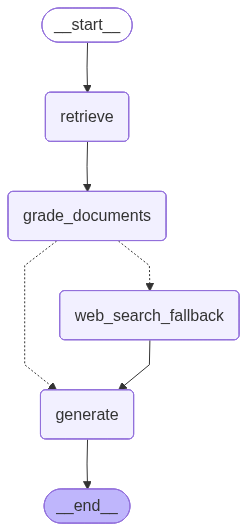

In [12]:
# The branching topology — note the conditional edge from grade_documents
display(Image(rag_app.get_graph().draw_mermaid_png()))

In [13]:
# Test 1: question answerable from the blog — should route directly to generate
print("=" * 60)
print("TEST 1: Question answerable from blog content")
print("=" * 60)

result = rag_app.invoke({"question": "What is a node?"})
print(f"\nAnswer:\n{result['generation']}")

TEST 1: Question answerable from blog content
Retrieving documents for: What is a node?
  Retrieved 3 documents
Grading document relevance...


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning='Re...ode.', is_relevant=True), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [RELEVANT] See Node Status for more details.Node heartbeatsHeartbeats, ... — Relevant: discusses Kubernetes nodes (heartbeats, Lease objects, node controller) and node management details, which relate to what a node is and how it behaves. However it does not give a direct, concise definition of a node.


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning="Th...ion.", is_relevant=True), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [RELEVANT] a subset of the available nodes.Marking a node as unschedula... — The excerpt discusses Kubernetes Nodes (cordoning/unschedulable, status fields, heartbeats), so it is directly about nodes and contains information relevant to describing what a node is and how it behaves, even though it doesn't give a concise one-line definition.


/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(reasoning='Th...er.', is_relevant=False), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(


  [NOT RELEVANT] See Control Topology Management Policies on a Node
for more ... — This snippet is an index/listing of links about Kubernetes nodes (topics like components, API, autoscaling, taints) but does not provide a definition or explanation of what a node is. It points to pages that would answer the question, but by itself it is not a relevant answer.
  2/3 documents relevant
Generating answer from vector store...

Answer:
A **node** is a worker machine in a Kubernetes cluster (either a physical machine or a virtual machine) that runs your workloads (Pods) and sends status/heartbeat information back to the control plane so Kubernetes can manage scheduling and availability.
